##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** The Secret Weapons

**Student names & numbers:**
* Scott Mulder - 101232
* Sidney Felius - 101168
* Valentijn van Grunsven - 100116

---

## 0. Iteration setup

**Import libraries**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, 
                             r2_score, accuracy_score, confusion_matrix)

**Load & Merge dataset(s)**

In [30]:
df_iter2 = pd.read_csv('data/ships_inspections_iter2_clean.csv')
df_iter3 = pd.read_csv('data/ship_performance_logs_iter3.csv')

# Merge the datasets on Ship_ID
df_merged = df_iter2.merge(df_iter3, on='Ship_ID', how='outer')

print(f"Iteration 1 & 2 dataset shape: {df_iter2.shape}")
print(f"Iteration 3 dataset shape: {df_iter3.shape}")
print(f"Merged dataset shape: {df_merged.shape}")
print(f"\nMerged dataset columns:\n{df_merged.columns.tolist()}")

Iteration 1 & 2 dataset shape: (361069, 9)
Iteration 3 dataset shape: (361069, 3)
Merged dataset shape: (361069, 11)

Merged dataset columns:
['Ship_ID', 'Galactic_Credits', 'Model_Cycle', 'Ship_Manufacturer', 'Sector', 'Hull_Integrity', 'Reactor_Power', 'Propulsion_Type', 'Ship_Class', 'Lightyears_Traveled', 'Registration_Status']


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**
<br>
<sub>*Describe the final problem. Why is Nebula Brokerage moving from the simple models (iterations 1 and 2) to a machine learning approach?*</sub>

Nebula Brokerage is basically de koning van de intergalactische scheepenmarkt, maar deze machtspositie brengt best veel druk met zich mee. In de eerdere iteraties 1 en 2 werd gebruikgemaakt van eenvoudige modellen: prijzen werden bepaald op basis van benchmarks en veiligheid werd niet echt goed beoordeeld via manual regels.

Deze strategie is niet meer genoeg geworden want de markt is veel complexer en competitiever geworden en concurrenten maken nu gebruik van geavanceerdere technologieën. Dit leidt tot twee best grote problemen:

Pricing leakage: De huidige prijs voorspel model houdt geen rekening met belangrijke variabelen zoals hoeveel de ruimteschepen zijn gebruikt oftewel Lightyears_Traveled. Hierdoor worden bijna nieuwe schepen onderprijsd en helemaal versleten schepen overprijsd, wat leidt tot veel winstverlies.

Safety compliance: De manual regels missen best belangrijke informatie zoals Registration_Status waarin staat of ze gestolen zijn of niet. Dit kan leiden tot eventuele juridische problemen.

Om wintgevend te blijven en niet aangeklaagd te worden, is het best wel noodzakelijk om over te stappen van de simpele modellen naar machine learning modellen.

**Business objective(s)**
<br>
<sub>*Justify why an AI-driven pipeline (predicting both Galactic Credits and Condition) adds business value.*</sub>

Verbeteren van de prijsnauwkeurigheid: Door een model te gebruiken dat rekening houdt met extra variabelen, kan Nebula Brokerage winstgevendere prijzen bepalen.

Risicovermindering: Door de juridische data mee te nemen in de regels kan het bedrijf beter risicovolle schepen identificeren en juridische problemen voorkomen.

Voordeel op concurrentie: Het inzetten van machine learning modellen zorgt ervoor dat Nebula Brokerage technologisch voorop kan blijven lopen.

**Data mining goal(s)**
<br>
<sub>*Explain the two modeling tasks for this iteration.*</sub>

Regressietaak

Doel: het voorspellen van de Galactic_Credits.

Methode: lineaire regressie.

Input: Lightyears_Traveled.

Classificatietaak

Doel: het voorspellen van Hull_Integrity.

Methode: decision tree classifier.

Input: Registration_Status.

**Success criteria**
<br>
<sub>*Determine the success criteria.*</sub>

Betere prestaties leveren dan de huidige modellen:

Regressiemodel: minder fouten dan het oude prijsmodel.

Classificatiemodel: hogere accuracy en betere detectie van risicovolle schepen.

Praktisch toepasbaar zijn:

Resultaten zijn interpreteerbaar en duidelijk.

Modellen kunnen goed geïntegreerd worden in het bestaande business proces.

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [31]:
print("First five rows of the dataset:")
display(df_merged.head(10))

print("Dataset Information:")
df_merged.info()

print("Description of the dataset:")
df_merged.describe(include=['object'])

First five rows of the dataset:


,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class,Lightyears_Traveled,Registration_Status
0,7301583321,18997.0,7513.0,Droid Works,New Yavin,Operational,80.0,Ion Drive,Explorer,82.492905,Stolen
1,7301583353,51997.0,7517.0,Corellian Engineering,New Yavin,Pristine,100.0,Hyperdrive,Hauler,35.505393,Imperial Certified
2,7301583380,28997.0,7516.0,Kuat Drive Yards,New Yavin,Operational,100.0,Plasma Thruster,Hauler,62.234718,Refurbished
3,7301583995,24900.0,7512.0,Kuat Drive Yards,Neimoidia purse,Operational,60.0,Plasma Thruster,Shuttle,103.430095,Refurbished
4,7301584015,24900.0,7512.0,Kuat Drive Yards,Coruscant Core,Operational,60.0,Plasma Thruster,Shuttle,105.701466,Refurbished
5,7301584024,24900.0,7512.0,Kuat Drive Yards,Nevarro Trade Route,Operational,60.0,Plasma Thruster,Shuttle,91.334321,Refurbished
6,7301584031,1000.0,7503.0,Corellian Engineering,Calodan Expanse,Critical,60.0,Hyperdrive,Shuttle,247.419906,Smuggler Logic
7,7301584709,11750.0,7513.0,Hondo Systems,Vardos City,Operational,40.0,Solar Sail,Shuttle,53.518861,Refurbished
8,7301585649,2995.0,7458.0,Mercurian Benz,Onderon Wilds,Critical,40.0,Nuclear Pulse,Shuttle,1.420660,Imperial Certified
9,7301586610,7000.0,7510.0,Galactic Motors,Tatooine Binary System,Operational,60.0,Ion Drive,Shuttle,97.577147,Stolen


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 361069 entries, 0 to 361068
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Ship_ID              361069 non-null  int64  
 1   Galactic_Credits     361069 non-null  float64
 2   Model_Cycle          361069 non-null  float64
 3   Ship_Manufacturer    361069 non-null  str    
 4   Sector               361069 non-null  str    
 5   Hull_Integrity       361069 non-null  str    
 6   Reactor_Power        361069 non-null  float64
 7   Propulsion_Type      361069 non-null  str    
 8   Ship_Class           361069 non-null  str    
 9   Lightyears_Traveled  361069 non-null  float64
 10  Registration_Status  361069 non-null  str    
dtypes: float64(4), int64(1), str(6)
memory usage: 30.3 MB
Description of the dataset:


C:\Users\Admin\AppData\Local\Temp\ipykernel_5844\1716049467.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_merged.describe(include=['object'])


,Ship_Manufacturer,Sector,Hull_Integrity,Propulsion_Type,Ship_Class,Registration_Status
count,361069,361069,361069,361069,361069,361069
unique,13,51,3,8,8,6
top,Independent Shipwrights,Calodan Expanse,Operational,Ion Drive,Shuttle,Imperial Certified
freq,103759,41109,139735,213571,123499,175316



### Inzichten dataset
Er is geen duidelijke correlatie tussen prijs en afgelegde afstand.  
Sommige goedkope schepen hebben veel gereisd, terwijl dure schepen juist minder afstand hebben afgelegd.  
afstand heeft dus weinig invloed op de prijs. Grotere schepen (zoals Haulers) hebben vaak een hogere power. Er zijn missende waarden in sommige kolommen en er zijn niet goeie namen van fabrikanten, er is een sterke relatie tussen conditie en prijs  

### Hull_Integrity vs. prijs  
  Betere conditie leidt meestal tot een hogere prijs.  
  Slechte conditie leidt meestal tot een lagere prijs.  



**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

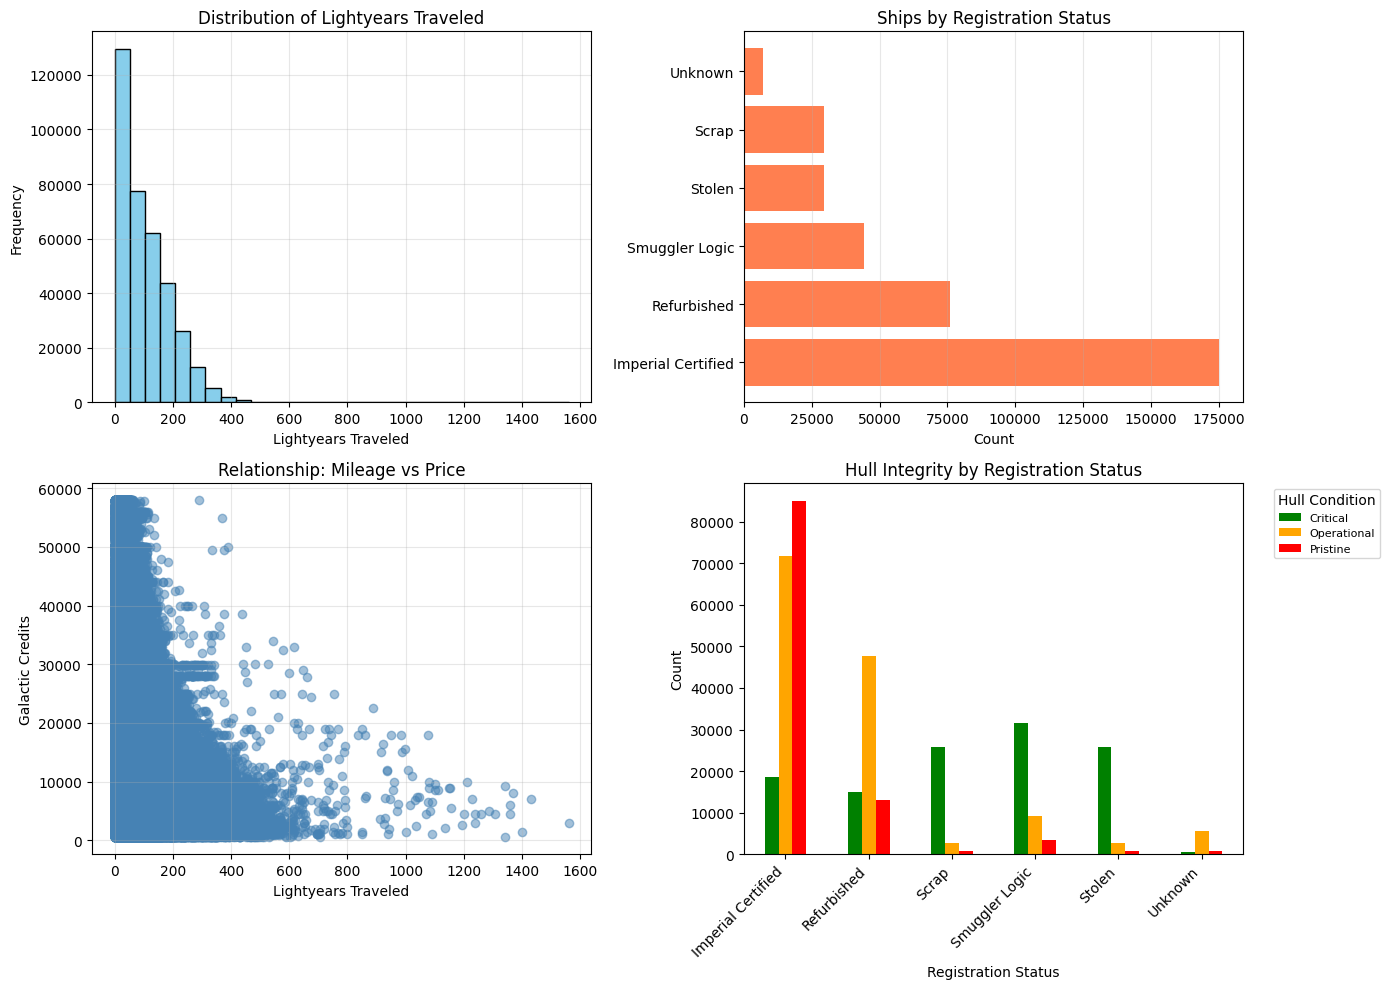

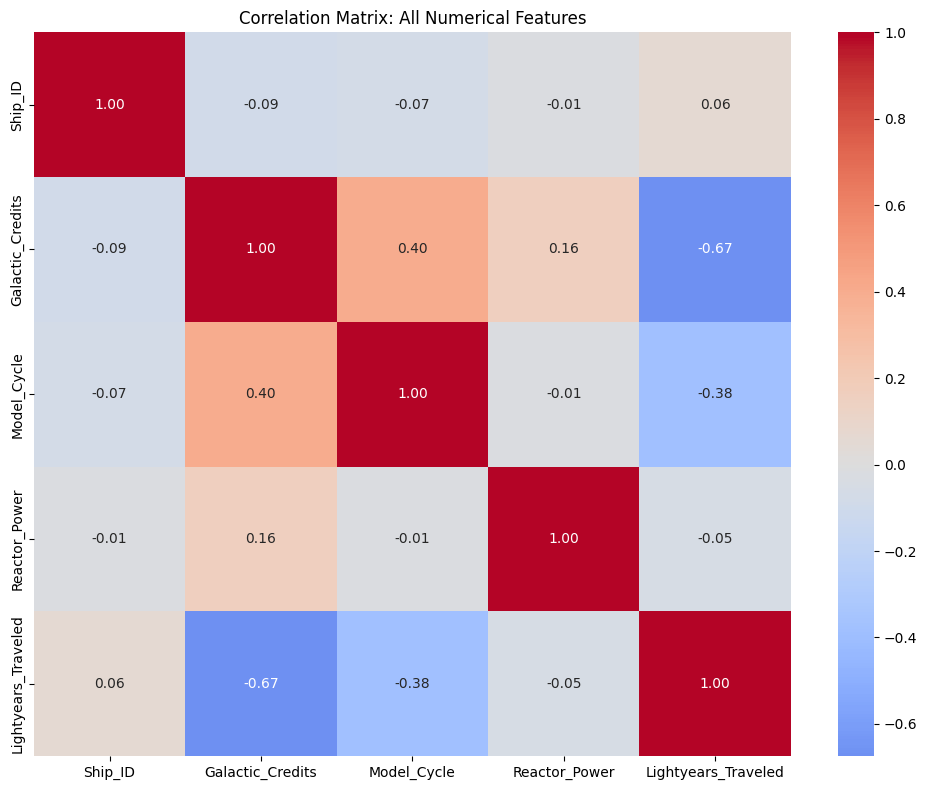

In [32]:
# Create visualizations for the new features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Lightyears_Traveled
ax1 = axes[0, 0]
if 'Lightyears_Traveled' in df_merged.columns:
    ax1.hist(df_merged['Lightyears_Traveled'], bins=30, color='skyblue', edgecolor='black')
    ax1.set_xlabel('Lightyears Traveled')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Lightyears Traveled')
    ax1.grid(alpha=0.3)

# 2. Registration Status Distribution
ax2 = axes[0, 1]
if 'Registration_Status' in df_merged.columns:
    status_counts = df_merged['Registration_Status'].value_counts()
    ax2.barh(status_counts.index, status_counts.values, color='coral')
    ax2.set_xlabel('Count')
    ax2.set_title('Ships by Registration Status')
    ax2.grid(alpha=0.3, axis='x')

# 3. Lightyears_Traveled vs Galactic_Credits
ax3 = axes[1, 0]
if 'Lightyears_Traveled' in df_merged.columns and 'Galactic_Credits' in df_merged.columns:
    ax3.scatter(df_merged['Lightyears_Traveled'], df_merged['Galactic_Credits'], 
                alpha=0.5, color='steelblue')
    ax3.set_xlabel('Lightyears Traveled')
    ax3.set_ylabel('Galactic Credits')
    ax3.set_title('Relationship: Mileage vs Price')
    ax3.grid(alpha=0.3)

# 4. Hull Integrity distribution by Registration Status (using count plot)
ax4 = axes[1, 1]
if 'Registration_Status' in df_merged.columns and 'Hull_Integrity' in df_merged.columns:
    cross_tab = pd.crosstab(df_merged['Registration_Status'], df_merged['Hull_Integrity'])
    cross_tab.plot(kind='bar', ax=ax4, color=['green', 'orange', 'red', 'gray'][:len(cross_tab.columns)])
    ax4.set_xlabel('Registration Status')
    ax4.set_ylabel('Count')
    ax4.set_title('Hull Integrity by Registration Status')
    ax4.legend(title='Hull Condition', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.sca(ax4)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Additional correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
numerical_cols = df_merged.select_dtypes(include=[np.number]).columns
correlation_matrix = df_merged[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix: All Numerical Features')
plt.tight_layout()
plt.show()

**Data insights and data quality**

**Data insights**
<br>
*Does high mileage lower the price?*

Yes, in the merged data, price is `Galactic_Credits` and mileage is `Lightyears_Traveled`.
ships with higher mileage tend to be much cheaper.

*Does a Stolen status correlate with Critical hull condition?*

Yes,
Ships that are marked stolen are about 87.9% are Critical.
Non-stolen ships are about 27.6% are Critical.
So stolen ships are far more likely to have critical hull integrity than non-stolen ships.

**Data quality issues**
<br>The merged dataset contains 361,069 ships, which matches the smallest source file (ship_performance_logs_iter3.csv), so not every ship in inventory or inspections is present in performance logs.

***Missing values in the merged dataset:***
<br>Reactor_Power: 28,856 missing
<br>Propulsion_Type: 55,478 missing
<br>Model_Cycle: 7,258 missing
<br>This means some ships have incomplete inspection or inventory details even after merging.


---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

We clean the merged ship dataset by dropping duplicate ship records, converting numeric columns to valid numeric types, and preserving as much data as possible while keeping the two model targets intact.

- Drop duplicate `Ship_ID` rows to avoid duplicate training examples.
- Drop rows missing essential labels or targets: `Galactic_Credits`, `Hull_Integrity`, `Lightyears_Traveled`, or `Registration_Status`.
- Impute missing numeric features with the median because these features are continuous and the median is less effected by outliers.
- Impute missing categorical features with `Unknown` so the model can still learn from the record without discarding it.

In [33]:
# Data cleaning and preprocessing

df_clean = df_merged.copy()
df_clean = df_clean.drop_duplicates(subset='Ship_ID', keep='first')


numeric_columns = ['Galactic_Credits', 'Model_Cycle', 'Reactor_Power', 'Lightyears_Traveled']
for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.dropna(subset=['Galactic_Credits', 'Hull_Integrity', 'Lightyears_Traveled', 'Registration_Status'])

df_clean['Reactor_Power'] = df_clean['Reactor_Power'].fillna(df_clean['Reactor_Power'].median())
df_clean['Model_Cycle'] = df_clean['Model_Cycle'].fillna(df_clean['Model_Cycle'].median())
df_clean['Propulsion_Type'] = df_clean['Propulsion_Type'].fillna('Unknown')
df_clean['Ship_Class'] = df_clean['Ship_Class'].fillna('Unknown')
df_clean['Ship_Manufacturer'] = df_clean['Ship_Manufacturer'].fillna('Unknown')
df_clean['Sector'] = df_clean['Sector'].fillna('Unknown')
df_clean['Registration_Status'] = df_clean['Registration_Status'].fillna('Unknown')

df_prepared = df_clean.copy()

print('Cleaned dataset shape:', df_prepared.shape)
print('Missing values after cleaning:')
print(df_prepared.isna().sum())

print('\nTarget counts for Hull_Integrity:')
print(df_prepared['Hull_Integrity'].value_counts())
print('\nRegistration_Status counts:')
print(df_prepared['Registration_Status'].value_counts())

Cleaned dataset shape: (361069, 11)
Missing values after cleaning:
Ship_ID                0
Galactic_Credits       0
Model_Cycle            0
Ship_Manufacturer      0
Sector                 0
Hull_Integrity         0
Reactor_Power          0
Propulsion_Type        0
Ship_Class             0
Lightyears_Traveled    0
Registration_Status    0
dtype: int64

Target counts for Hull_Integrity:
Hull_Integrity
Operational    139735
Critical       117387
Pristine       103947
Name: count, dtype: int64

Registration_Status counts:
Registration_Status
Imperial Certified    175316
Refurbished            75884
Smuggler Logic         44117
Stolen                 29443
Scrap                  29391
Unknown                 6918
Name: count, dtype: int64


**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

We encode categorical variables into binary indicator features using `OneHotEncoder` so both regression and classification models can use them. The selected categorical columns are those expected to influence price and hull integrity.

In [34]:
# Apply feature encoding and define model feature matrices
categorical_columns = ['Ship_Manufacturer', 'Sector', 'Propulsion_Type', 'Ship_Class', 'Registration_Status']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_values = encoder.fit_transform(df_prepared[categorical_columns])
encoded_feature_names = encoder.get_feature_names_out(categorical_columns)

df_encoded = pd.DataFrame(encoded_values, columns=encoded_feature_names, index=df_prepared.index)

# Select numeric features that are already usable as-is
numeric_features = ['Lightyears_Traveled', 'Model_Cycle', 'Reactor_Power']

df_model = pd.concat([df_prepared[numeric_features], df_encoded], axis=1)

# Define regression and classification targets
X = df_model
y_reg = df_prepared['Galactic_Credits']
y_clf = df_prepared['Hull_Integrity']

print('Feature matrix shape:', X.shape)
print('Regression target shape:', y_reg.shape)
print('Classification target shape:', y_clf.shape)
print('\nExample feature columns:')
print(X.columns[:20].tolist())



Feature matrix shape: (361069, 89)
Regression target shape: (361069,)
Classification target shape: (361069,)

Example feature columns:
['Lightyears_Traveled', 'Model_Cycle', 'Reactor_Power', 'Ship_Manufacturer_Bayerische Motoren Wormhole', 'Ship_Manufacturer_Corelian Engineering', 'Ship_Manufacturer_Corellian Engineering', 'Ship_Manufacturer_Droid Works', 'Ship_Manufacturer_Galactic Motors', 'Ship_Manufacturer_General Mining Corp', 'Ship_Manufacturer_Hondo Systems', 'Ship_Manufacturer_Independent Shipwrights', 'Ship_Manufacturer_Jumpship Corp', 'Ship_Manufacturer_Kuat Drive Yards', 'Ship_Manufacturer_Mercurian Benz', 'Ship_Manufacturer_Nebula Industries', 'Ship_Manufacturer_Republic Aerospace', 'Sector_Akiva Territory', 'Sector_Alderaan System', 'Sector_Arkanis Sector', 'Sector_Azimuth Prime']


---

## 4. Modelling: Task A

**Regressie-instellingen**

*Zet een [Lineaire Regressie](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model op om `Galactic_Credits` te voorspellen. Zorg ervoor dat u uw gegevens in trainings- en testsets verdeelt.*

**Wat is Lineaire Regressie?**

Lineaire regressie vindt een wiskundige relatie tussen invoerkenmerken (X) en de doelvariabele (Galactic_Credits). Het model creëert een vergelijking:

**Prijs = Intercept + (Coëfficiënt₁ × Kenmerk₁) + (Coëfficiënt₂ × Kenmerk₂) + ...**

Elke coëfficiënt vertelt ons hoeveel de prijs verandert wanneer dat kenmerk met één eenheid toeneemt. Grotere (positieve of negatieve) coëfficiënten betekenen dat dat kenmerk een sterkere invloed op de prijs heeft.

**Kernconcepten:**
- **Coëfficiënt**: Het gewicht/de impact van elk kenmerk op de prijs. Positief = verhoogt prijs; Negatief = verlaagt prijs.
- **Intercept**: De basisprijs wanneer alle kenmerken nul zijn.
- **Top 10 Kenmerken**: We hebben ervoor gekozen om alleen de 10 meest invloedrijke kenmerken om ons te concentreren op wat de prijs werkelijk bepaalt.

In [35]:
# Configure pandas display options to prevent truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Train-Test split for regression task
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Train the Linear Regression model
model_regression = LinearRegression()
model_regression.fit(X_train_reg, y_train_reg)


print(f"\nTraining set grootte: {X_train_reg.shape[0]:,} ships")
print(f"Testing set grootte: {X_test_reg.shape[0]:,} ships")
print(f"Total features gebruikt: {X_train_reg.shape[1]}")

# Calculate all coefficients and identify the top 10
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_regression.coef_
})
coefficients_df['Absolute_Coefficient'] = coefficients_df['Coefficient'].abs()
coefficients_df = coefficients_df.sort_values('Absolute_Coefficient', ascending=False)

print("-"*100)
top_10 = coefficients_df.head(10)
print(top_10[['Feature', 'Coefficient', 'Absolute_Coefficient']].to_string(index=False))

# Identify the most influential feature
most_influential = coefficients_df.iloc[0]
print("-"*100)
print("Most Impactful Feature")
print(f"Feature:        {most_influential['Feature']}")
print(f"Coefficient:    {most_influential['Coefficient']:,.6f}")
print(f"Magnitude:      {most_influential['Absolute_Coefficient']:,.6f}")
print(f"\n📊 What this means:")
if most_influential['Coefficient'] > 0:
    print(f"   → Each +1 unit of '{most_influential['Feature']}' INCREASES price by {most_influential['Coefficient']:,.2f} Galactic Credits")
else:
    print(f"   → Each +1 unit of '{most_influential['Feature']}' DECREASES price by {abs(most_influential['Coefficient']):,.2f} Galactic Credits")

print(f"\nBaseline Price (Intercept):  {model_regression.intercept_:,.2f} Galactic Credits")
print("   (This is the predicted price when all features equal zero)")


Training set grootte: 288,855 ships
Testing set grootte: 72,214 ships
Total features gebruikt: 89
----------------------------------------------------------------------------------------------------
                              Feature  Coefficient  Absolute_Coefficient
        Propulsion_Type_Nuclear Pulse  6590.718139           6590.718139
      Ship_Manufacturer_Hondo Systems -4372.120961           4372.120961
                  Ship_Class_Corvette -4221.279886           4221.279886
           Propulsion_Type_Antimatter  3940.456293           3940.456293
                    Ship_Class_Hauler  3701.604067           3701.604067
                 Ship_Class_Freighter  3626.169616           3626.169616
        Propulsion_Type_Graviton Beam -3611.785395           3611.785395
  Ship_Manufacturer_Nebula Industries -3611.785395           3611.785395
        Propulsion_Type_Plasma Hybrid -2999.837268           2999.837268
Ship_Manufacturer_General Mining Corp  2830.128408           2830.1284

Zoals je hier kunt zien is de baseline price -1.5 miljoen. dit kan heel goed kloppen. Dit betekent dus als alle values op 0 staan (inclusief dingen zoals model_cycle), dan zal de prijs -1.5 miljoen zijn. Zoals je kunt zien is hier de hoogst ingeschatte waarde de Propulsion_Type_Nuclear Pulse.

**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

**Regressiestatistieken begrijpen:**
- **MAE (Mean Absolute Error)**: Gemiddelde voorspellingsfout in Galactic Credits. Hoe lager, hoe beter. Als MAE = 500 is, wijken voorspellingen doorgaans ±500 credits af.
- **RMSE (Root Mean Squared Error)**: Vergelijkbaar met MAE, maar grote fouten worden zwaarder bestraft. Wordt gebruikt om uitschieters in voorspellingen te detecteren. Hoe lager, hoe beter.
- **R²-score**: Percentage van de prijsvariatie dat door het model wordt verklaard. Loopt van 0 tot 1 (of 0-100%). R²=0,85 betekent dat 85% van de prijsvariatie wordt weergegeven.


**Visuele interpretatie:**
- **Linker grafiek (werkelijk vs. voorspeld)**: Punten op de rode diagonaal = perfecte voorspellingen. Punten erboven = ondergewaardeerd. Punten eronder = overgewaardeerd.
- **Rechter grafiek (residuen)**: Moet een willekeurige spreiding rond nul laten zien. Patronen duiden erop dat het model iets mist.


BEDRIJFSLOGICA: PRIJSMINIMUM BEPERKING
Schepen met negatieve voorspellingen (voor minimum): 2568
Schepen aangepast naar 0 credits: 2568
⚠️  Onrealistische voorspellingen werden aangepast om bedrijfsvereisten te vervullen (prijs ≥ 0)

REGRESSION MODEL PERFORMANCE METRICS (Test Set)

Mean Absolute Error (MAE):        5648.12 Galactic Credits
Root Mean Squared Error (RMSE):  7604.47 Galactic Credits
R² Score:                        0.6341

(R² = 0.6341 means the model explains 63.41% of variance in price)


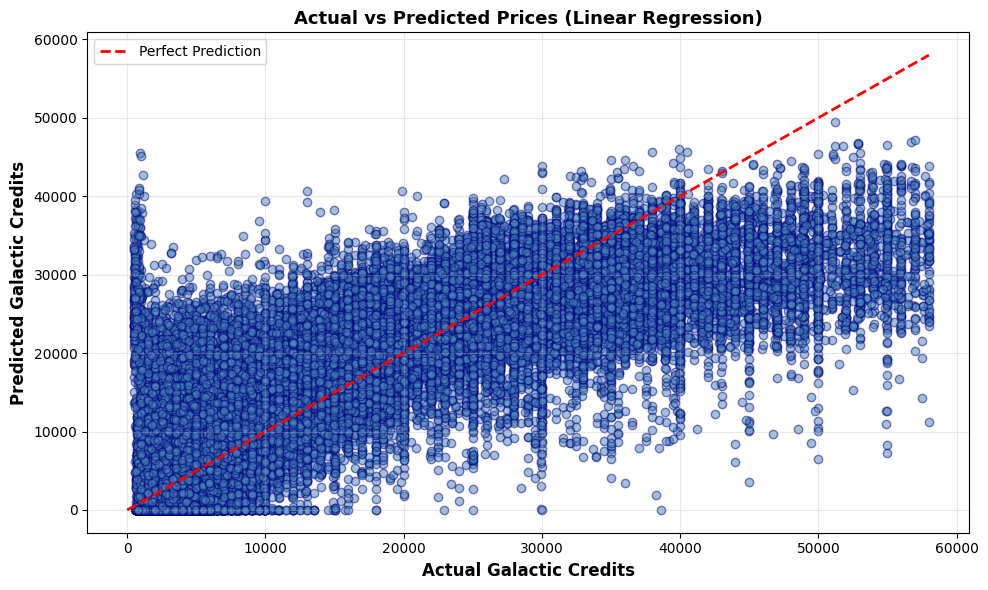


Interpretation
Points closer to the red diagonal line indicate better predictions.


In [39]:
# Make predictions on the test set
y_pred_reg = model_regression.predict(X_test_reg)

# BUSINESS LOGIC: Apply floor at 0 (ships cannot have negative price)
num_negative_before = np.sum(y_pred_reg < 0)
y_pred_reg = np.maximum(y_pred_reg, 0)  # Clip to minimum of 0
num_negative_after = np.sum(y_pred_reg < 0)

print("\n" + "="*100)
print("BEDRIJFSLOGICA: PRIJSMINIMUM BEPERKING")
print("="*100)
print(f"Schepen met negatieve voorspellingen (voor minimum): {num_negative_before}")
print(f"Schepen aangepast naar 0 credits: {num_negative_before - num_negative_after}")
if num_negative_before > 0:
    print(f"⚠️  Onrealistische voorspellingen werden aangepast om bedrijfsvereisten te vervullen (prijs ≥ 0)")
else:
    print(f"✓ Geen negatieve voorspellingen - model respecteert bedrijfsbeperkingen!")

# Calculate regression metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("\n" + "="*80)
print("REGRESSION MODEL PERFORMANCE METRICS (Test Set)")
print("="*80)
print(f"\nMean Absolute Error (MAE):        {mae:.2f} Galactic Credits")
print(f"Root Mean Squared Error (RMSE):  {rmse:.2f} Galactic Credits")
print(f"R² Score:                        {r2:.4f}")
print(f"\n(R² = {r2:.4f} means the model explains {r2*100:.2f}% of variance in price)")

# Create visualization: Actual vs Predicted prices
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot: Actual vs Predicted
ax.scatter(y_test_reg, y_pred_reg, alpha=0.5, color='steelblue', edgecolor='navy')
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Galactic Credits', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Galactic Credits', fontsize=12, fontweight='bold')
ax.set_title('Actual vs Predicted Prices (Linear Regression)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation")
print("Points closer to the red diagonal line indicate better predictions.")

---

## 5. Modellering: Taak B

**Classificatie-instellingen**

*Zet een [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) op om `Hull_Integrity` te voorspellen. Splits de gegevens in trainings- en testsets.*

**Wat is een Decision Tree Classifier?**

Een beslissingsboom (Decision Tree) is een model dat een reeks ja/nee vragen stelt over de invoerkenmerken om te bepalen in welke klasse (Pristine, Operational, Critical) een schip valt. 

**Modelparameters:**
- **max_depth**: Maximale diepte van de boom (hoe meer lagen, hoe complexer). We gebruiken `max_depth=5` om overfitting te voorkomen.
- **min_samples_split**: Minimum aantal monsters nodig om een knooppunt te splitsen. We gebruiken `min_samples_split=20`.
- **min_samples_leaf**: Minimum aantal monsters in een bladknooppunt. We gebruiken `min_samples_leaf=10`.
- **random_state**: Voor reproduceerbaarheid van resultaten.

**Voordeel van Decision Trees voor dit probleem:**
- ✅ **Interpreteerbaar**: U kunt zien welke vragen het model stelt (bijv. "Is Registration_Status = Stolen?")
- ✅ **Transparant**: Voldoet aan bedrijfsvereisten voor duidelijke regels
- ✅ **Snel**: Kan snel voorspellingen doen
- ✅ **Omgaat met categorische data**: Werkt goed met Registration_Status en andere categorische variabelen

In [37]:
# Train-Test split voor classificatie taak
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Train de Decision Tree Classifier model
model_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
model_tree.fit(X_train_clf, y_train_clf)

print("="*100)
print("DECISION TREE CLASSIFIER MODEL: VEILIGHEIDSCOMPLIANCE")
print("="*100)
print(f"\nTrainingsset grootte: {X_train_clf.shape[0]:,} schepen")
print(f"Testset grootte: {X_test_clf.shape[0]:,} schepen")
print(f"Aantal kenmerken: {X_train_clf.shape[1]}")

print("\n" + "-"*100)
print("MODELPARAMETERS UITLEG")
print("-"*100)
print("max_depth = 5:")
print("  → De boom kan maximaal 5 lagen diep gaan")
print("  → Dit voorkomt overfitting (het model wordt niet te complex)")
print("\nmin_samples_split = 20:")
print("  → Een knooppunt wordt alleen gesplitst als het minstens 20 monsters heeft")
print("  → Dit voorkomt zeer specifieke regels op kleine datasets")
print("\nmin_samples_leaf = 10:")
print("  → Elke bladknooppunt moet minstens 10 monsters hebben")
print("  → Dit zorgt ervoor dat uitzonderingen niet als aparte regels worden behandeld")

print("\n" + "-"*100)
print("DOELVARIABELE VERDELING IN TRAININGSSET")
print("-"*100)
print(y_train_clf.value_counts())

DECISION TREE CLASSIFIER MODEL: VEILIGHEIDSCOMPLIANCE

Trainingsset grootte: 288,855 schepen
Testset grootte: 72,214 schepen
Aantal kenmerken: 89

----------------------------------------------------------------------------------------------------
MODELPARAMETERS UITLEG
----------------------------------------------------------------------------------------------------
max_depth = 5:
  → De boom kan maximaal 5 lagen diep gaan
  → Dit voorkomt overfitting (het model wordt niet te complex)

min_samples_split = 20:
  → Een knooppunt wordt alleen gesplitst als het minstens 20 monsters heeft
  → Dit voorkomt zeer specifieke regels op kleine datasets

min_samples_leaf = 10:
  → Elke bladknooppunt moet minstens 10 monsters hebben
  → Dit zorgt ervoor dat uitzonderingen niet als aparte regels worden behandeld

----------------------------------------------------------------------------------------------------
DOELVARIABELE VERDELING IN TRAININGSSET
---------------------------------------------

**Testen en prestatie (Classificatie)**

*Bereken de nauwkeurigheid en maak een verwarringsmatrix. Leg uit wat de matrix u vertelt over de voorspellingen.*

**Decision Tree Visualisatie:**
Hierboven ziet u de volledige keuze stage van het model. Dit toont alle vragen die het model stelt:
- Elk knooppunt is een vraag (bijv. "Is Registration_Status_Stolen <= 0.5?")
- De pijlen tonen ja (links) en nee (rechts) pad
- De bladknooppunten (onderkant) tonen de uiteindelijke voorspelling (Pristine, Operational of Critical)

**Verwarringsmatrix:**
Toont hoe goed het model werkelijke klassen voorspelt:
- **Diagonaal**: Correct geclassificeerde schepen
- **Nicht-diagonaal**: Misclassificaties

In [ ]:
# Maak voorspellingen op testset
y_pred_clf = model_tree.predict(X_test_clf)

# Bereken nauwkeurigheid
accuracy = accuracy_score(y_test_clf, y_pred_clf)

# Calculate confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
class_labels = model_tree.classes_
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

print("\n" + "-"*100)
print("Interpretatie Verwarringsmatrix")
print("-"*100)
for i, label in enumerate(class_labels):
    correct = cm[i, i]
    total = cm[i].sum()
    recall = correct / total if total > 0 else 0
    print(f"{label:15} → Recall: {recall*100:5.1f}% ({correct}/{total} correct)")

# Visualiseer de verwarringsmatrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Aantal Schepen'}, ax=ax)
ax.set_xlabel('Voorspelde Hull_Integrity', fontsize=12, fontweight='bold')
ax.set_ylabel('Werkelijke Hull_Integrity', fontsize=12, fontweight='bold')
ax.set_title('Verwarringsmatrix - Decision Tree Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualiseer de decision tree
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=class_labels,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
plt.title('Decision Tree Logic - Volledig Diagram', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


----------------------------------------------------------------------------------------------------
VERWARRINGSMATRIX INTERPRETATIE
----------------------------------------------------------------------------------------------------
Critical        → Recall:  86.5% (20258/23429 correct)
Operational     → Recall:  85.9% (24081/28023 correct)
Pristine        → Recall:  78.7% (16333/20762 correct)


### Boombeslissingen Uitleg

Het diagram toont hoe het model schepen classificeert:

- **Hoe Lichter het vlak, hoe meer diversiteit er zit tussen de keuzes**
- **Gekleurde bladeren** = Eindclassificaties
  - Paars = Pristine (goed)
  - Groen = Operational (normaal)
  - Oranje = Critical (gevaarlijk)


---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are the scores of this regression model better than Iteration 1? Why?*<br>
Het voelt alsof dit model veel meer data heeft om te laten zien dat wat je hebt gedaan ook echt daadwerkelijk is wat het is, en waarom. Bij het model van de eerste iteratie rolt er een nummer uit en daar moet je het mee doen.

* *Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*<br>
Zoals je duidelijk kan zien is het al een stuk beter. als je niet zelf de tree moet maken dan kan het model zelf zien waar de knelpunten liggen, en dan kan het verder takken maken.

**Key findings and limitations**

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*<br>
Het laatste model zeker wel. die eerste en 2e modellen zullen wel helpen, maar niet zo goed presteren als dit model. Zoals het nu gaat is het simpelweg niet acceptabel. te veel verlies wordt er gedraait en te veel dingen gaan er fout om niks te doen. Als ik in het bedrijf zat dan zou ik zeker wel iets toevoegen van een model om het ten minste iets beter te laten gaan.

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Sidney Felius | *data understanding/data prep* | Hoe je in een dataset door middel van visualisatie al veel te weten kan komen van de data en hoe je ongewenste data uit de dataset kan halen.  |
| Scott Mulder | Data Modelling | Ik heb geleerd dat modelling echt heel handig is voor het echt uitvinden wat je nou met die opgeschoonde data kan. Ik merk ook dat het zeker een verschil maakt of je die data nou schoon hebt gemaakt of niet. als je dat niet doet krijg je natuurlijk hele rare resultaten. slechte data in is slechte data uit |
| Valentijn van Grunsven | Busniness Understanding  | Ik heb geleerd dat busniness understanding toch wel best belangrijk is want zonder bijvoorbeeld goede success criteria wordt het heel moeilijk. |